
# CNN–BiLSTM Walk-Forward + Optuna Pipeline for Silver Forecasting

This notebook is a cleaned notebook version of your uploaded pipeline, with targeted code changes that are justified by the original file structure:

- wider Optuna search space
- sequence-context handling for validation and test windows
- refit on the full outer-train after selecting the best epoch
- optional ensemble evaluation across saved seed runs

It keeps the same overall workflow:

1. load cleaned dataframe
2. chronological outer split
3. Optuna walk-forward tuning on outer-train only
4. refit preprocessing on full outer-train
5. final multi-seed evaluation on untouched outer-test
6. save reports and models


In [ ]:

# =========================
# 1) Drive Mount + Install Dependencies
# =========================
from google.colab import drive
drive.mount('/content/drive')

!pip -q install optuna tensorflow scikit-learn pandas numpy matplotlib


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 769.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 162.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 146.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 613.9/613.9 kB 52.1 MB/s eta 0:00:00


In [ ]:

# =========================
# 2) Imports
# =========================
import os
import json
import pickle
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import optuna
from optuna.samplers import TPESampler


In [ ]:
# =========================
# 3) User Inputs
# =========================
# Replace this path with your actual cleaned dataframe file.
CLEAN_DF_PATH = "/content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_RRL_interpolate_plus2.csv"

# Set your target column here.
TARGET_COL = "Silver_Futures"

# Set this if your file has a real date column that should be used for chronological sorting.
# Example: DATE_COL = "Date"
DATE_COL = "Date"

# Forecast setting
HORIZON = 1

# Outer split
OUTER_TRAIN_RATIO = 0.80

# Internal validation from the tail of outer-train for final seed runs
FINAL_VAL_RATIO_WITHIN_OUTER_TRAIN = 0.10

# Optuna tuning settings
TUNING_SEED = 42
N_SPLITS_WALK_FORWARD = 5
INIT_POINTS = 15
N_ITER = 45

# Final seed evaluation
FINAL_SEEDS = [0, 1, 2, 42, 99, 123]

# Training settings
MAX_EPOCHS_TUNING = 60
MAX_EPOCHS_FINAL = 60
EARLY_STOPPING_PATIENCE = 10

# Save settings
SAVE_ALL_SEED_MODELS = True
SAVE_ROOT_DIR = "/content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm_04/07(7pm)"
REPORTS_DIR = "/content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_interpolated_plus2_saved_reports_improved_1cnn_1bilstm_04/07(7pm)"


PBOUNDS = {
    "lookback": (10, 12),
    "filters": (30, 36),
    "kernel_size": (2, 3),
    "lstm_units": (34, 42),
    "dense_units": (12, 18),
    "dropout_rate": (0.06, 0.12),
    "learning_rate": (1.45e-4, 1.75e-4),
    "batch_size_exp": (4, 4),  # fixed batch size = 16
}

In [ ]:

# =========================
# 4) Reproducibility Helper
# =========================
def set_global_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


In [ ]:
# =========================
# 5) Load Cleaned DataFrame
# =========================
df = pd.read_csv(CLEAN_DF_PATH)

# --- Validate target first
if TARGET_COL not in df.columns:
    raise ValueError(f"TARGET_COL '{TARGET_COL}' is not present in the dataframe.")

# --- Handle date column properly
if DATE_COL is not None and DATE_COL in df.columns:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)
    df = df.set_index(DATE_COL)

# --- Ensure target is numeric
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

# --- Keep only numeric columns for modeling
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if TARGET_COL not in numeric_cols:
    raise ValueError(f"TARGET_COL '{TARGET_COL}' must be numeric and present in the dataframe.")

df = df[numeric_cols].copy()

# --- Horizon alignment: predict t+1 using current/past information only
MODEL_TARGET_COL = "target_t_plus_1"
df[MODEL_TARGET_COL] = df[TARGET_COL].shift(-HORIZON)

# --- Remove inf/-inf first
df = df.replace([np.inf, -np.inf], np.nan)

# --- Drop rows with invalid target after shifting
df = df.dropna(subset=[MODEL_TARGET_COL]).copy()

print("Cleaned working dataframe shape:", df.shape)
display(df.head())
display(df.tail())

print("\nNaN count per column:")
print(df.isna().sum().sort_values(ascending=False).head(20))

Cleaned working dataframe shape: (2545, 9)


,Silver_Futures,Gold_Futures,US30,SnP500,NASDAQ_100,USD_index,T10Y2Y,IGREA,target_t_plus_1
Date,,,,,,,,,
2015-04-01,17.059,1208.2,17698.2,2059.7,4311.26,98.190002,1.32,-96.726032,16.701
2015-04-02,16.701,1200.9,17763.2,2067.0,4316.01,97.440002,1.37,-96.699724,17.110
2015-04-06,17.110,1218.6,17880.8,2080.6,4350.98,97.110001,1.41,-96.594492,16.840
2015-04-07,16.840,1210.6,17875.4,2076.3,4344.08,97.830002,1.37,-96.568184,16.454
2015-04-08,16.454,1203.1,17902.5,2081.9,4375.96,98.070000,1.38,-96.541876,16.176


,Silver_Futures,Gold_Futures,US30,SnP500,NASDAQ_100,USD_index,T10Y2Y,IGREA,target_t_plus_1
Date,,,,,,,,,
2025-04-23,33.547000,3294.100000,39577.5,5375.86,18693.26,99.72,0.59,-23.563474,33.503000
2025-04-24,33.503000,3348.600000,40069.0,5484.77,19214.40,99.31,0.55,-23.563474,32.988998
2025-04-25,32.988998,3282.399902,40126.5,5525.21,19432.56,99.58,0.55,-23.563474,33.165000
2025-04-28,33.165000,3333.000000,40255.0,5528.75,19427.29,99.01,0.56,-23.563474,33.577000
2025-04-29,33.577000,3333.600000,40520.0,5560.83,19544.95,99.14,0.54,-23.563474,32.828000



NaN count per column:
Silver_Futures     0
Gold_Futures       0
US30               0
SnP500             0
NASDAQ_100         0
USD_index          0
T10Y2Y             0
IGREA              0
target_t_plus_1    0
dtype: int64


In [ ]:

# =========================
# 6) Chronological Outer Split: 80% Train, 20% Test
# =========================
outer_train_size = int(len(df) * OUTER_TRAIN_RATIO)

df_train_outer = df.iloc[:outer_train_size].copy().reset_index(drop=True)
df_test = df.iloc[outer_train_size:].copy().reset_index(drop=True)

print("df_train_outer shape:", df_train_outer.shape)
print("df_test shape:", df_test.shape)
print()
print("Outer-train index span:", df_train_outer.index.min(), "to", df_train_outer.index.max())
print("Test index span:", df_test.index.min(), "to", df_test.index.max())


df_train_outer shape: (2036, 9)
df_test shape: (509, 9)

Outer-train index span: 0 to 2035
Test index span: 0 to 508


In [ ]:

# =========================
# 7) Feature / Target Split
# =========================
feature_cols = [col for col in df_train_outer.columns if col != MODEL_TARGET_COL]
print("Number of features:", len(feature_cols))
print(feature_cols)

X_train_outer_raw = df_train_outer[feature_cols].copy()
y_train_outer_raw = df_train_outer[[MODEL_TARGET_COL]].copy()

X_test_raw = df_test[feature_cols].copy()
y_test_raw = df_test[[MODEL_TARGET_COL]].copy()


Number of features: 8
['Silver_Futures', 'Gold_Futures', 'US30', 'SnP500', 'NASDAQ_100', 'USD_index', 'T10Y2Y', 'IGREA']


In [ ]:

# =========================
# 8) Sequence Builders
# =========================
def create_sequences(X_df, y_df, lookback):
    X_values = X_df.values
    y_values = y_df.values.reshape(-1)

    X_seq, y_seq = [], []
    for i in range(lookback, len(X_df)):
        X_seq.append(X_values[i - lookback:i, :])
        y_seq.append(y_values[i])

    return np.array(X_seq), np.array(y_seq)


def create_sequences_with_context(X_prev, y_prev, X_block, y_block, lookback):
    """
    Build validation/test sequences using the immediately preceding training context.
    This avoids dropping boundary history at train/validation and train/test transitions.
    """
    X_full = pd.concat([X_prev.tail(lookback), X_block], axis=0).reset_index(drop=True)
    y_full = pd.concat([y_prev.tail(lookback), y_block], axis=0).reset_index(drop=True)
    return create_sequences(X_full, y_full, lookback)


In [ ]:
# =========================
# 9) Model Builder
# =========================
def build_cnn_bilstm(input_shape, params):
    model = Sequential([
        Input(shape=input_shape),

        Conv1D(
            filters=params["filters"],
            kernel_size=params["kernel_size"],
            activation="relu",
            padding="same"
        ),
        MaxPooling1D(pool_size=2),
        Dropout(params["dropout_rate"]),

        Bidirectional(
            LSTM(
                params["lstm_units"],
                activation="tanh",
                return_sequences=False
            )
        ),
        Dropout(params["dropout_rate"]),

        Dense(params["dense_units"], activation="relu"),
        Dropout(params["dropout_rate"]),

        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=params["learning_rate"]),
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    return model

In [ ]:
# =========================
# 10) Optuna Objective
# =========================
optuna_trial_logs = []


def optuna_objective(trial):
    set_global_seed(TUNING_SEED)

    params = {
        "lookback": trial.suggest_int(
            "lookback",
            int(PBOUNDS["lookback"][0]),
            int(PBOUNDS["lookback"][1])
        ),
        "filters": trial.suggest_int(
            "filters",
            int(PBOUNDS["filters"][0]),
            int(PBOUNDS["filters"][1])
        ),
        "kernel_size": trial.suggest_int(
            "kernel_size",
            int(PBOUNDS["kernel_size"][0]),
            int(PBOUNDS["kernel_size"][1])
        ),
        "lstm_units": trial.suggest_int(
            "lstm_units",
            int(PBOUNDS["lstm_units"][0]),
            int(PBOUNDS["lstm_units"][1])
        ),
        "dense_units": trial.suggest_int(
            "dense_units",
            int(PBOUNDS["dense_units"][0]),
            int(PBOUNDS["dense_units"][1])
        ),
        "dropout_rate": trial.suggest_float(
            "dropout_rate",
            float(PBOUNDS["dropout_rate"][0]),
            float(PBOUNDS["dropout_rate"][1])
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate",
            float(PBOUNDS["learning_rate"][0]),
            float(PBOUNDS["learning_rate"][1]),
            log=True
        ),
        "batch_size_exp": trial.suggest_int(
            "batch_size_exp",
            int(PBOUNDS["batch_size_exp"][0]),
            int(PBOUNDS["batch_size_exp"][1])
        ),
    }

    params["batch_size"] = int(2 ** params["batch_size_exp"])

    # Safety clamps
    params["lookback"] = max(2, params["lookback"])
    params["filters"] = max(4, params["filters"])
    params["kernel_size"] = max(1, params["kernel_size"])
    params["lstm_units"] = max(4, params["lstm_units"])
    params["dense_units"] = max(4, params["dense_units"])
    params["batch_size"] = max(8, params["batch_size"])

    tscv = TimeSeriesSplit(n_splits=N_SPLITS_WALK_FORWARD)
    fold_rmses = []

    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(df_train_outer), start=1):
        fold_train_raw = df_train_outer.iloc[train_idx].copy().reset_index(drop=True)
        fold_val_raw = df_train_outer.iloc[val_idx].copy().reset_index(drop=True)

        X_fold_train_raw = fold_train_raw[feature_cols].copy()
        y_fold_train_raw = fold_train_raw[[MODEL_TARGET_COL]].copy()

        X_fold_val_raw = fold_val_raw[feature_cols].copy()
        y_fold_val_raw = fold_val_raw[[MODEL_TARGET_COL]].copy()

        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        X_fold_train_scaled = pd.DataFrame(
            scaler_X.fit_transform(X_fold_train_raw),
            columns=feature_cols
        )
        X_fold_val_scaled = pd.DataFrame(
            scaler_X.transform(X_fold_val_raw),
            columns=feature_cols
        )

        y_fold_train_scaled = pd.DataFrame(
            scaler_y.fit_transform(y_fold_train_raw),
            columns=[MODEL_TARGET_COL]
        )
        y_fold_val_scaled = pd.DataFrame(
            scaler_y.transform(y_fold_val_raw),
            columns=[MODEL_TARGET_COL]
        )

        X_train_seq, y_train_seq = create_sequences(
            X_fold_train_scaled,
            y_fold_train_scaled,
            params["lookback"]
        )

        # Important change: use train-tail context for validation sequence creation
        X_val_seq, y_val_seq = create_sequences_with_context(
            X_fold_train_scaled,
            y_fold_train_scaled,
            X_fold_val_scaled,
            y_fold_val_scaled,
            params["lookback"]
        )

        if len(X_train_seq) == 0 or len(X_val_seq) == 0:
            return float("inf")

        model = build_cnn_bilstm(
            input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
            params=params
        )

        es = EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=0
        )

        model.fit(
            X_train_seq,
            y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=MAX_EPOCHS_TUNING,
            batch_size=params["batch_size"],
            shuffle=False,
            verbose=0,
            callbacks=[es]
        )

        y_val_pred_scaled = model.predict(X_val_seq, verbose=0).reshape(-1, 1)
        y_val_true_scaled = y_val_seq.reshape(-1, 1)

        y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled).reshape(-1)
        y_val_true = scaler_y.inverse_transform(y_val_true_scaled).reshape(-1)

        fold_rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
        fold_rmses.append(fold_rmse)

        trial.report(float(fold_rmse), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    mean_rmse = float(np.mean(fold_rmses))

    optuna_trial_logs.append({
        "trial_number": trial.number,
        "params": params.copy(),
        "fold_rmses": fold_rmses.copy(),
        "mean_rmse": mean_rmse,
    })

    return mean_rmse

In [ ]:

# =========================
# 11) Run Optuna Study
# =========================
set_global_seed(TUNING_SEED)

sampler = TPESampler(seed=TUNING_SEED)
pruner = optuna.pruners.MedianPruner(
    n_startup_trials=max(5, INIT_POINTS),
    n_warmup_steps=2
)

study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    pruner=pruner,
    study_name="cnn_bilstm_walkforward_optuna"
)

study.optimize(
    optuna_objective,
    n_trials=INIT_POINTS + N_ITER,
    show_progress_bar=False
)

print("Best Optuna result:")
print("Best trial number:", study.best_trial.number)
print("Best objective (mean RMSE):", study.best_value)
print("Best params:", study.best_trial.params)


[I 2026-04-04 21:41:34,545] A new study created in memory with name: cnn_bilstm_walkforward_optuna
[I 2026-04-04 21:42:17,383] Trial 0 finished with value: 1.2876165299003384 and parameters: {'lookback': 11, 'filters': 36, 'kernel_size': 3, 'lstm_units': 39, 'dense_units': 13, 'dropout_rate': 0.06935967122017216, 'learning_rate': 0.00014659248047046633, 'batch_size_exp': 4}. Best is trial 0 with value: 1.2876165299003384.
[I 2026-04-04 21:43:12,365] Trial 1 finished with value: 1.2204978222245035 and parameters: {'lookback': 12, 'filters': 34, 'kernel_size': 3, 'lstm_units': 34, 'dense_units': 18, 'dropout_rate': 0.1099465584480253, 'learning_rate': 0.00015090712570323378, 'batch_size_exp': 4}. Best is trial 1 with value: 1.2204978222245035.
[I 2026-04-04 21:43:53,401] Trial 2 finished with value: 1.230576998102813 and parameters: {'lookback': 10, 'filters': 31, 'kernel_size': 2, 'lstm_units': 38, 'dense_units': 15, 'dropout_rate': 0.07747374841188251, 'learning_rate': 0.00016268145820

Best Optuna result:
Best trial number: 44
Best objective (mean RMSE): 0.903751062880653
Best params: {'lookback': 12, 'filters': 35, 'kernel_size': 2, 'lstm_units': 39, 'dense_units': 16, 'dropout_rate': 0.10142668743647931, 'learning_rate': 0.00016908784058132723, 'batch_size_exp': 4}


In [ ]:
# =========================
# 11) Extract Best Hyperparameters
# =========================
best_raw = study.best_trial.params

best_params = {
    "lookback": int(best_raw["lookback"]),
    "filters": int(best_raw["filters"]),
    "kernel_size": int(best_raw["kernel_size"]),
    "lstm_units": int(best_raw["lstm_units"]),
    "dense_units": int(best_raw["dense_units"]),
    "dropout_rate": float(best_raw["dropout_rate"]),
    "learning_rate": float(best_raw["learning_rate"]),
    "batch_size": int(2 ** int(best_raw["batch_size_exp"])),
}

print("Best hyperparameters after conversion:")
print(best_params)


Best hyperparameters after conversion:
{'lookback': 12, 'filters': 35, 'kernel_size': 2, 'lstm_units': 39, 'dense_units': 16, 'dropout_rate': 0.10142668743647931, 'learning_rate': 0.00016908784058132723, 'batch_size': 16}


In [ ]:
# =========================
# 12) Report Per-Trial Per-Fold RMSE from Optuna Walk-Forward
# =========================
optuna_report_rows = []

print("=" * 100)
print("OPTUNA WALK-FORWARD TUNING REPORT")
print("=" * 100)

for log_idx, trial in enumerate(sorted(optuna_trial_logs, key=lambda x: x["trial_number"]), start=1):
    row = {
        "logged_trial_index": log_idx,
        "trial_number": trial["trial_number"],
        "mean_rmse": trial["mean_rmse"],
    }
    print(f"Trial {trial['trial_number']}")
    print("Params:", trial["params"])
    for fold_i, rmse in enumerate(trial["fold_rmses"], start=1):
        print(f"  Fold {fold_i} RMSE = {rmse:.6f}")
        row[f"fold_{fold_i}_rmse"] = rmse
    print(f"  Mean RMSE = {trial['mean_rmse']:.6f}")
    print("-" * 100)
    optuna_report_rows.append(row)

bayes_report_df = pd.DataFrame(optuna_report_rows)
display(bayes_report_df)


OPTUNA WALK-FORWARD TUNING REPORT
Trial 0
Params: {'lookback': 11, 'filters': 36, 'kernel_size': 3, 'lstm_units': 39, 'dense_units': 13, 'dropout_rate': 0.06935967122017216, 'learning_rate': 0.00014659248047046633, 'batch_size_exp': 4, 'batch_size': 16}
  Fold 1 RMSE = 0.948418
  Fold 2 RMSE = 0.679976
  Fold 3 RMSE = 1.363681
  Fold 4 RMSE = 1.977731
  Fold 5 RMSE = 1.468277
  Mean RMSE = 1.287617
----------------------------------------------------------------------------------------------------
Trial 1
Params: {'lookback': 12, 'filters': 34, 'kernel_size': 3, 'lstm_units': 34, 'dense_units': 18, 'dropout_rate': 0.1099465584480253, 'learning_rate': 0.00015090712570323378, 'batch_size_exp': 4, 'batch_size': 16}
  Fold 1 RMSE = 0.758098
  Fold 2 RMSE = 1.092559
  Fold 3 RMSE = 1.184133
  Fold 4 RMSE = 1.766966
  Fold 5 RMSE = 1.300732
  Mean RMSE = 1.220498
----------------------------------------------------------------------------------------------------
Trial 2
Params: {'lookback': 

,logged_trial_index,trial_number,mean_rmse,fold_1_rmse,fold_2_rmse,fold_3_rmse,fold_4_rmse,fold_5_rmse
0,1,0,1.287617,0.948418,0.679976,1.363681,1.977731,1.468277
1,2,1,1.220498,0.758098,1.092559,1.184133,1.766966,1.300732
2,3,2,1.230577,1.012731,0.820276,1.715932,1.252301,1.351644
3,4,3,1.456343,1.928310,0.821623,1.177924,2.012459,1.341398
4,5,4,1.293649,1.184979,1.027708,1.420347,1.462560,1.372649
5,6,5,1.136149,1.559736,0.541820,1.184546,1.082799,1.311842
6,7,6,1.142611,0.950171,0.890265,1.793798,0.958390,1.120433
7,8,7,1.111171,0.649142,0.719642,1.333422,1.481608,1.372043
8,9,8,1.175427,1.220086,1.125032,1.251347,1.045339,1.235329
9,10,9,1.316887,1.160096,0.963355,1.367287,1.685145,1.408554


In [ ]:
# =========================
# 13) Leakage-Free Final Split and Scalers
# =========================
LOOKBACK = best_params["lookback"]

# Split outer-train into final-fit and final-validation BEFORE fitting scalers
n_train_outer_raw = len(df_train_outer)
n_val_raw_final = max(1, int(n_train_outer_raw * FINAL_VAL_RATIO_WITHIN_OUTER_TRAIN))
n_fit_raw_final = n_train_outer_raw - n_val_raw_final

df_fit_final_raw = df_train_outer.iloc[:n_fit_raw_final].copy().reset_index(drop=True)
df_val_final_raw = df_train_outer.iloc[n_fit_raw_final:].copy().reset_index(drop=True)

X_fit_final_raw = df_fit_final_raw[feature_cols].copy()
y_fit_final_raw = df_fit_final_raw[[MODEL_TARGET_COL]].copy()

X_val_final_raw = df_val_final_raw[feature_cols].copy()
y_val_final_raw = df_val_final_raw[[MODEL_TARGET_COL]].copy()

# Scalers for BEST-EPOCH selection (fit on final-fit only to avoid leakage)
scaler_X_epoch = MinMaxScaler()
scaler_y_epoch = MinMaxScaler()

X_fit_final_scaled = pd.DataFrame(
    scaler_X_epoch.fit_transform(X_fit_final_raw),
    columns=feature_cols
)

y_fit_final_scaled = pd.DataFrame(
    scaler_y_epoch.fit_transform(y_fit_final_raw),
    columns=[MODEL_TARGET_COL]
)

X_val_final_scaled = pd.DataFrame(
    scaler_X_epoch.transform(X_val_final_raw),
    columns=feature_cols
)

y_val_final_scaled = pd.DataFrame(
    scaler_y_epoch.transform(y_val_final_raw),
    columns=[MODEL_TARGET_COL]
)

print("Final-fit raw shape:", X_fit_final_raw.shape, y_fit_final_raw.shape)
print("Final-validation raw shape:", X_val_final_raw.shape, y_val_final_raw.shape)
print("Leakage-free epoch-selection scaled shapes:",
      X_fit_final_scaled.shape, y_fit_final_scaled.shape,
      X_val_final_scaled.shape, y_val_final_scaled.shape)



Final-fit raw shape: (1833, 8) (1833, 1)
Final-validation raw shape: (203, 8) (203, 1)
Leakage-free epoch-selection scaled shapes: (1833, 8) (1833, 1) (203, 8) (203, 1)


In [ ]:
# =========================
# 14) Final Sequences for Epoch Selection and Final Refit
# =========================
# Sequences used only to choose the best epoch (validation keeps train-tail context)
X_fit_final_seq, y_fit_final_seq = create_sequences(
    X_fit_final_scaled,
    y_fit_final_scaled,
    LOOKBACK
)

X_val_final_seq, y_val_final_seq = create_sequences_with_context(
    X_fit_final_scaled,
    y_fit_final_scaled,
    X_val_final_scaled,
    y_val_final_scaled,
    LOOKBACK
)

print("Epoch-selection fit sequences:", X_fit_final_seq.shape, y_fit_final_seq.shape)
print("Epoch-selection validation sequences:", X_val_final_seq.shape, y_val_final_seq.shape)

# Refit scalers on FULL outer-train after best epoch is chosen
scaler_X_final = MinMaxScaler()
scaler_y_final = MinMaxScaler()

X_train_outer_scaled = pd.DataFrame(
    scaler_X_final.fit_transform(X_train_outer_raw),
    columns=feature_cols
)

y_train_outer_scaled = pd.DataFrame(
    scaler_y_final.fit_transform(y_train_outer_raw),
    columns=[MODEL_TARGET_COL]
)

X_test_scaled = pd.DataFrame(
    scaler_X_final.transform(X_test_raw),
    columns=feature_cols
)

y_test_scaled = pd.DataFrame(
    scaler_y_final.transform(y_test_raw),
    columns=[MODEL_TARGET_COL]
)

# Final refit uses ALL outer-train sequences
X_train_outer_seq, y_train_outer_seq = create_sequences(
    X_train_outer_scaled,
    y_train_outer_scaled,
    LOOKBACK
)

# Final test uses outer-train tail as context so the first test prediction has proper history
X_test_seq, y_test_seq = create_sequences_with_context(
    X_train_outer_scaled,
    y_train_outer_scaled,
    X_test_scaled,
    y_test_scaled,
    LOOKBACK
)

print("Full outer-train sequences for final refit:", X_train_outer_seq.shape, y_train_outer_seq.shape)
print("Final test sequences with context:", X_test_seq.shape, y_test_seq.shape)



Epoch-selection fit sequences: (1821, 12, 8) (1821,)
Epoch-selection validation sequences: (203, 12, 8) (203,)
Full outer-train sequences for final refit: (2024, 12, 8) (2024,)
Final test sequences with context: (509, 12, 8) (509,)


In [ ]:
# =========================
# 15) Final Stage Summary
# =========================
print("LOOKBACK used for final stage:", LOOKBACK)
print("Best epoch will be selected on leakage-free validation,")
print("then the model will be refit on the FULL outer-train before testing.")



LOOKBACK used for final stage: 12
Best epoch will be selected on leakage-free validation,
then the model will be refit on the FULL outer-train before testing.


In [ ]:
# =========================
# 16) Save / Load Helpers for Inference
# =========================
import json
import os
import pickle

def save_forecasting_artifacts(
    model,
    save_dir: str,
    x_scaler,
    feature_cols,
    target_col: str,
    lookback: int,
    y_scaler=None,
    model_name: str = "final_model.keras",
    extra_metadata: dict | None = None,
) -> None:
    os.makedirs(save_dir, exist_ok=True)

    # Save trained Keras model
    model.save(os.path.join(save_dir, model_name))

    # Save scalers
    with open(os.path.join(save_dir, "x_scaler.pkl"), "wb") as f:
        pickle.dump(x_scaler, f)

    if y_scaler is not None:
        with open(os.path.join(save_dir, "y_scaler.pkl"), "wb") as f:
            pickle.dump(y_scaler, f)

    # Save metadata
    metadata = {
        "feature_cols": list(feature_cols),
        "target_col": target_col,
        "lookback": int(lookback),
        "model_file": model_name,
        "has_y_scaler": y_scaler is not None,
    }
    if extra_metadata is not None:
        metadata.update(extra_metadata)

    with open(os.path.join(save_dir, "model_metadata.pkl"), "wb") as f:
        pickle.dump(metadata, f)

    with open(os.path.join(save_dir, "model_metadata.json"), "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=4)

def load_forecasting_artifacts(save_dir: str):
    with open(os.path.join(save_dir, "model_metadata.pkl"), "rb") as f:
        metadata = pickle.load(f)

    model = tf.keras.models.load_model(os.path.join(save_dir, metadata["model_file"]))

    with open(os.path.join(save_dir, "x_scaler.pkl"), "rb") as f:
        x_scaler = pickle.load(f)

    y_scaler = None
    if metadata.get("has_y_scaler", False):
        with open(os.path.join(save_dir, "y_scaler.pkl"), "rb") as f:
            y_scaler = pickle.load(f)

    return model, x_scaler, y_scaler, metadata

os.makedirs(SAVE_ROOT_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
print(f"Model save root: {SAVE_ROOT_DIR}")
print(f"Reports dir: {REPORTS_DIR}")


Model save root: /content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm(3am)
Reports dir: /content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_interpolated_plus2_saved_reports_improved_1cnn_1bilstm(3am)


In [ ]:
# =========================
# 17) Train Final Models Across Seeds, Evaluate, and Save ALL Seed Models
# =========================
final_results = []
seed_histories = {}
seed_predictions = {}

for seed in FINAL_SEEDS:
    print("\n" + "=" * 100)
    print(f"SEED {seed}")
    print("=" * 100)

    # ------------------------------------------------------------------
    # Step A: Choose best epoch using leakage-free internal validation
    # ------------------------------------------------------------------
    set_global_seed(seed)

    epoch_selector_model = build_cnn_bilstm(
        input_shape=(X_fit_final_seq.shape[1], X_fit_final_seq.shape[2]),
        params=best_params
    )

    es = EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=0
    )

    history = epoch_selector_model.fit(
        X_fit_final_seq,
        y_fit_final_seq,
        validation_data=(X_val_final_seq, y_val_final_seq),
        epochs=MAX_EPOCHS_FINAL,
        batch_size=best_params["batch_size"],
        shuffle=False,
        verbose=0,
        callbacks=[es]
    )

    seed_histories[seed] = history

    print(f"\nPer-epoch loss and val_loss for seed {seed}:")
    print("epoch\tloss\t\tval_loss")
    for epoch_idx, (loss_value, val_loss_value) in enumerate(
        zip(history.history["loss"], history.history["val_loss"]), start=1
    ):
        print(f"{epoch_idx}\t{loss_value:.8f}\t{val_loss_value:.8f}")

    best_epoch_idx = int(np.argmin(history.history["val_loss"]))
    best_epoch = int(best_epoch_idx + 1)
    best_loss = float(history.history["loss"][best_epoch_idx])
    best_val_loss = float(history.history["val_loss"][best_epoch_idx])

    # ------------------------------------------------------------------
    # Step B: Refit on FULL outer-train for exactly best_epoch epochs
    # ------------------------------------------------------------------
    set_global_seed(seed)

    final_model = build_cnn_bilstm(
        input_shape=(X_train_outer_seq.shape[1], X_train_outer_seq.shape[2]),
        params=best_params
    )

    final_model.fit(
        X_train_outer_seq,
        y_train_outer_seq,
        epochs=best_epoch,
        batch_size=best_params["batch_size"],
        shuffle=False,
        verbose=0
    )

    # Evaluate on untouched outer test (with proper train-tail context)
    y_pred_test_scaled = final_model.predict(X_test_seq, verbose=0).reshape(-1, 1)
    y_true_test_scaled = y_test_seq.reshape(-1, 1)

    y_pred_test = scaler_y_final.inverse_transform(y_pred_test_scaled).reshape(-1)
    y_true_test = scaler_y_final.inverse_transform(y_true_test_scaled).reshape(-1)

    rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
    r2 = r2_score(y_true_test, y_pred_test)

    print(
        f"\nSeed {seed} -> best_epoch={best_epoch}, "
        f"best_loss={best_loss:.8f}, best_val_loss={best_val_loss:.8f}, "
        f"RMSE={rmse:.6f}, R²={r2:.6f}"
    )

    final_results.append({
        "seed": seed,
        "best_epoch": best_epoch,
        "best_loss": best_loss,
        "best_val_loss": best_val_loss,
        "rmse_test": rmse,
        "r2_test": r2,
    })

    seed_predictions[seed] = {
        "y_true_test": y_true_test,
        "y_pred_test": y_pred_test,
    }

    # Save every trained seed model with all inference artifacts
    if SAVE_ALL_SEED_MODELS:
        seed_dir = os.path.join(SAVE_ROOT_DIR, f"seed_{seed}")
        save_forecasting_artifacts(
            model=final_model,
            save_dir=seed_dir,
            x_scaler=scaler_X_final,
            y_scaler=scaler_y_final,
            feature_cols=feature_cols,
            target_col=MODEL_TARGET_COL,
            lookback=best_params["lookback"],
            model_name=f"cnn_bilstm_seed{seed}.keras",
            extra_metadata={
                "seed": seed,
                "horizon": HORIZON,
                "best_params": best_params,
                "rmse_test": float(rmse),
                "r2_test": float(r2),
                "best_epoch": best_epoch,
            },
        )
        print(f"Saved seed {seed} artifacts to: {seed_dir}")




SEED 0

Per-epoch loss and val_loss for seed 0:
epoch	loss		val_loss
1	0.02677520	0.01319509
2	0.01759656	0.00999514
3	0.01325703	0.01042172
4	0.00954675	0.01177434
5	0.00843181	0.01162128
6	0.00853276	0.01223631
7	0.00710150	0.00996772
8	0.00708964	0.01368813
9	0.00702789	0.01487571
10	0.00666870	0.01354908
11	0.00673328	0.00770145
12	0.00655994	0.00667244
13	0.00653812	0.00801766
14	0.00604322	0.00836123
15	0.00644695	0.00958439
16	0.00635972	0.01204921
17	0.00661031	0.01361881
18	0.00538231	0.01298858
19	0.00567633	0.01408545
20	0.00600163	0.01147453
21	0.00523354	0.01114881
22	0.00474689	0.01202868

Seed 0 -> best_epoch=12, best_loss=0.00655994, best_val_loss=0.00667244, RMSE=1.207876, R²=0.903732
Saved seed 0 artifacts to: /content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm(3am)/seed_0

SEED 1

Per-epoch loss and val_loss for seed 1:
epoch	loss		val_loss
1	0.040822

In [ ]:
# =========================
# 18) Per-Seed RMSE and R² Report
# =========================
final_results_df = pd.DataFrame(final_results)
print("=" * 100)
print("PER-SEED FINAL TEST RESULTS")
print("=" * 100)
display(final_results_df)

rmse_mean = final_results_df["rmse_test"].mean()
rmse_std = final_results_df["rmse_test"].std(ddof=1)

r2_mean = final_results_df["r2_test"].mean()
r2_std = final_results_df["r2_test"].std(ddof=1)

loss_mean = final_results_df["best_loss"].mean()
loss_std = final_results_df["best_loss"].std(ddof=1)

val_loss_mean = final_results_df["best_val_loss"].mean()
val_loss_std = final_results_df["best_val_loss"].std(ddof=1)

print("\nSUMMARY ACROSS SEEDS")
print(f"RMSE  = {rmse_mean:.6f} ± {rmse_std:.6f}")
print(f"R²    = {r2_mean:.6f} ± {r2_std:.6f}")
print(f"Loss  = {loss_mean:.8f} ± {loss_std:.8f}")
print(f"Val loss = {val_loss_mean:.8f} ± {val_loss_std:.8f}")

PER-SEED FINAL TEST RESULTS


,seed,best_epoch,best_loss,best_val_loss,rmse_test,r2_test
0,0,12,0.006560,0.006672,1.207876,0.903732
1,1,3,0.024674,0.010384,3.800718,0.046836
2,2,11,0.009438,0.006524,1.359745,0.878002
3,42,6,0.014865,0.007053,2.693906,0.521148
4,99,7,0.009296,0.003967,1.777383,0.791552
5,123,4,0.013732,0.007394,1.610664,0.828823



SUMMARY ACROSS SEEDS
RMSE  = 2.075048 ± 0.992857
R²    = 0.661682 ± 0.331050
Loss  = 0.01309412 ± 0.00645174
Val loss = 0.00699908 ± 0.00205632


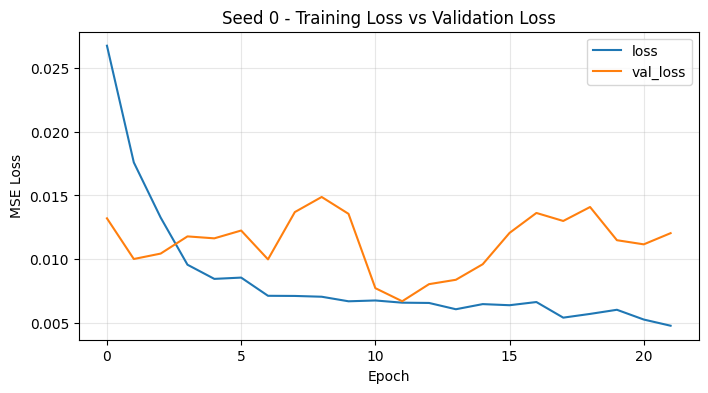

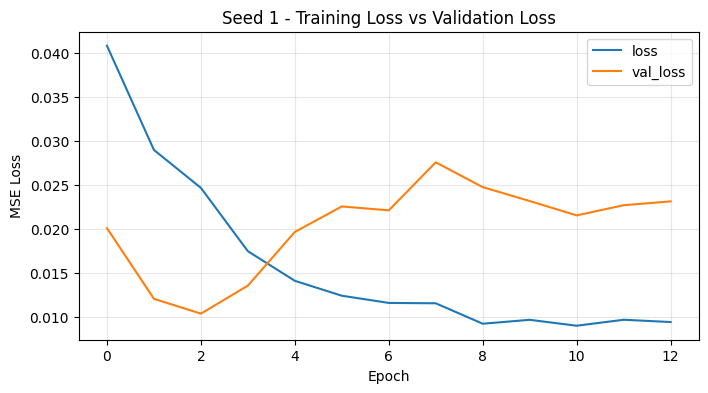

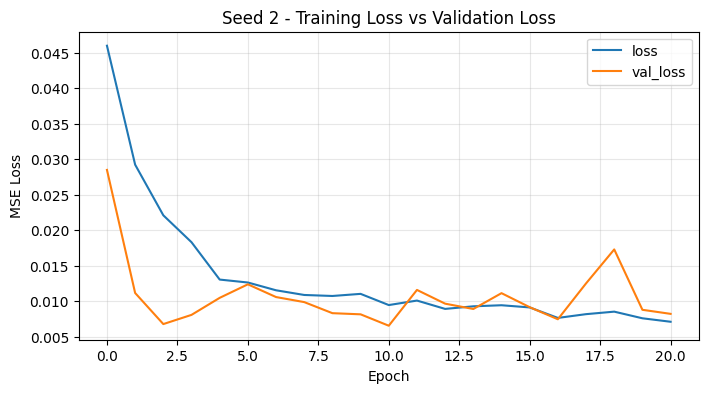

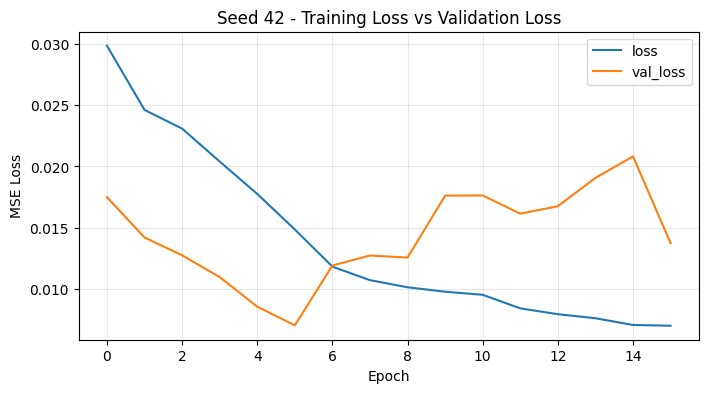

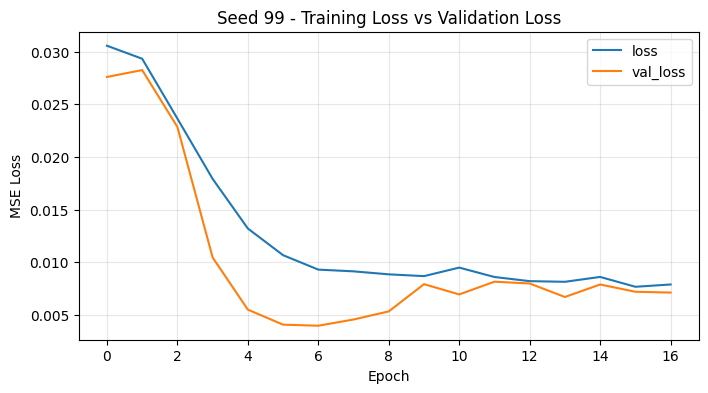

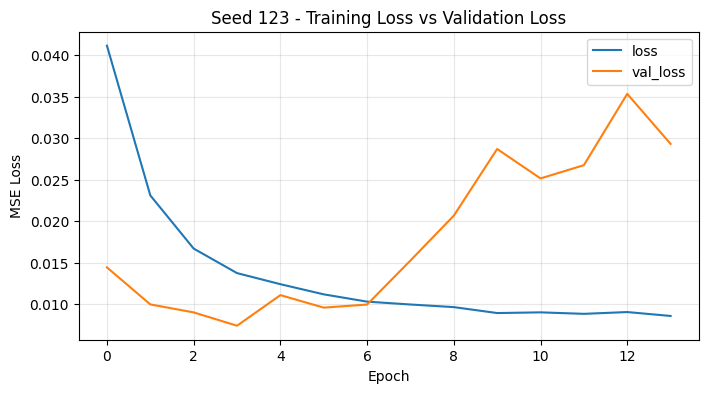

In [ ]:
# =========================
# 19) Plot Every Per-Seed Loss vs Val_Loss
# =========================
for seed in FINAL_SEEDS:
    history = seed_histories[seed]

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"Seed {seed} - Training Loss vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

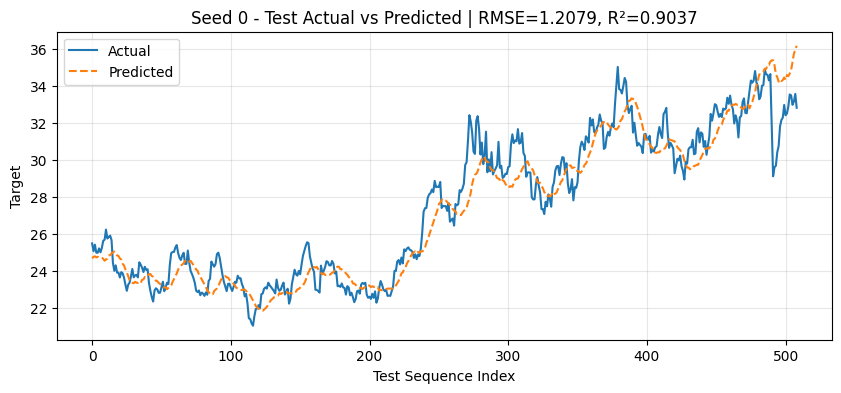

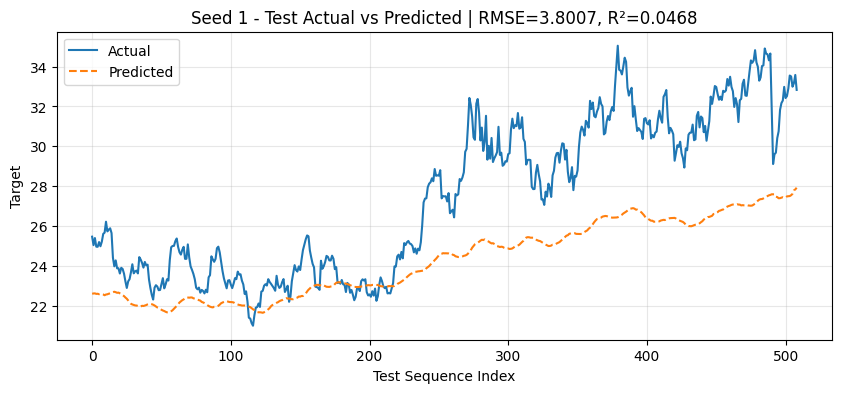

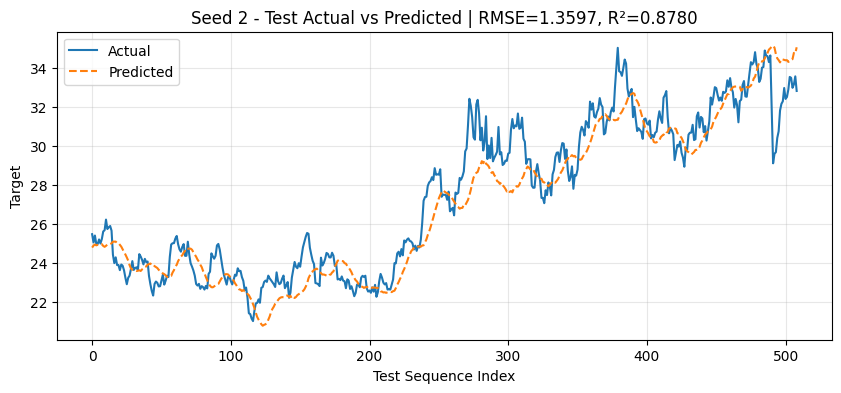

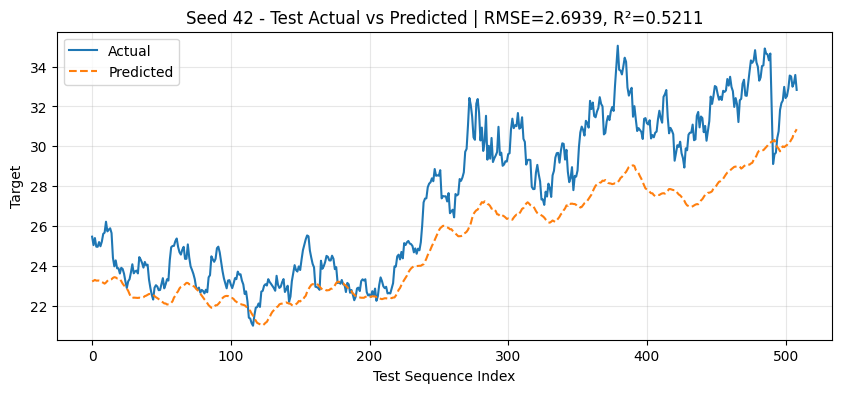

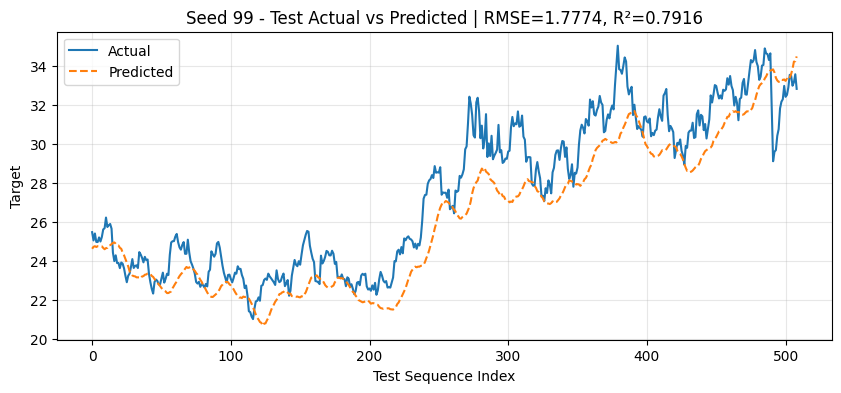

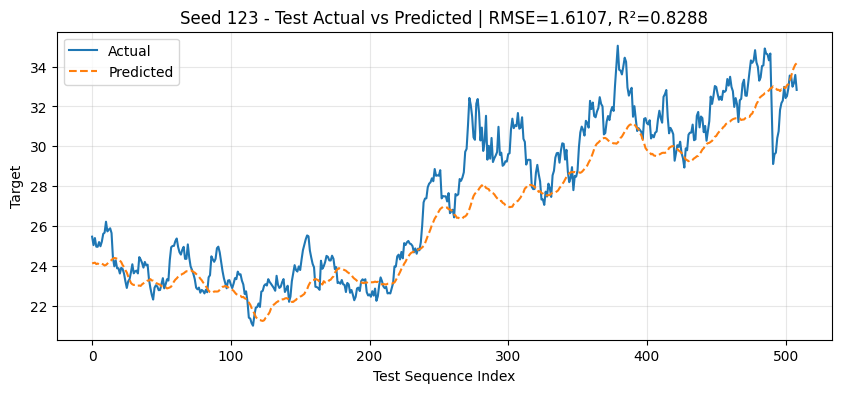

In [ ]:
# =========================
# 20) Plot Every Per-Seed Predicted vs Actual on df_test
# =========================
for seed in FINAL_SEEDS:
    y_true_test = seed_predictions[seed]["y_true_test"]
    y_pred_test = seed_predictions[seed]["y_pred_test"]

    rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
    r2 = r2_score(y_true_test, y_pred_test)

    plt.figure(figsize=(10, 4))
    plt.plot(y_true_test, label="Actual")
    plt.plot(y_pred_test, label="Predicted", linestyle="--")
    plt.title(f"Seed {seed} - Test Actual vs Predicted | RMSE={rmse:.4f}, R²={r2:.4f}")
    plt.xlabel("Test Sequence Index")
    plt.ylabel("Target")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
# =========================
# 21) Save Final Reports
# =========================
final_results_path = os.path.join(REPORTS_DIR, "silver_yahoo_final_seed_results.csv")
optuna_report_path = os.path.join(REPORTS_DIR, "silver_yahoo_optuna_walkforward_report.csv")
best_params_path = os.path.join(REPORTS_DIR, "silver_yahoo_best_params.json")

bayes_report_df.to_csv(optuna_report_path, index=False)
final_results_df.to_csv(final_results_path, index=False)

with open(best_params_path, "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=4)

print("Saved:")
print(f"- {optuna_report_path}")
print(f"- {final_results_path}")
print(f"- {best_params_path}")
print(f"- {SAVE_ROOT_DIR}/seed_*/")


Saved:
- /content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_interpolated_plus2_saved_reports_improved_1cnn_1bilstm(3am)/silver_yahoo_optuna_walkforward_report.csv
- /content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_interpolated_plus2_saved_reports_improved_1cnn_1bilstm(3am)/silver_yahoo_final_seed_results.csv
- /content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_interpolated_plus2_saved_reports_improved_1cnn_1bilstm(3am)/silver_yahoo_best_params.json
- /content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm(3am)/seed_*/
